In [1]:
# =========================================================
# RESPUESTA INSTITUCIONAL Y ACCESO A LA JUSTICIA
# TGEU Trans Murder Monitoring — Colombia
# =========================================================

# --- CELDA 1: Cargar el dataset limpio ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

col = pd.read_csv('/content/tgeu_colombia_limpio.csv')
print(f"Casos: {len(col)}")
print(col['Response from local authorities'].value_counts(dropna=False))

Casos: 306
Response from local authorities
NaN                              214
caso en investigación             70
autor detenido                    10
sospechoso identificado            4
caso desestimado                   2
autor acusado                      2
sospechoso declarado inocente      1
otro                               1
autor sentenciado                  1
sospechoso detenido                1
Name: count, dtype: int64


In [2]:
# --- CELDA 2: Construir la variable de tres niveles (no binaria) ---
# La versión anterior (binaria: True/False) mezclaba "no hubo respuesta"
# con "no sabemos si hubo respuesta", que son cosas muy distintas para
# un argumento de derechos humanos. Se separan en tres categorías reales:

SIN_ACCION_IDENTIFICADA = ['caso desestimado']
ACCION_IDENTIFICADA = [
    'caso en investigación', 'autor detenido', 'sospechoso identificado',
    'autor acusado', 'autor sentenciado', 'sospechoso detenido',
    'sospechoso declarado inocente', 'otro'
]

def clasificar_respuesta(valor):
    if pd.isna(valor):
        return 'Desconocida (sin información)'
    elif valor in SIN_ACCION_IDENTIFICADA:
        return 'Sin ninguna acción institucional identificada'
    elif valor in ACCION_IDENTIFICADA:
        return 'Alguna acción institucional identificada'
    else:
        return 'Desconocida (sin información)'

col['estado_respuesta_institucional'] = col['Response from local authorities'].apply(clasificar_respuesta)

conteo = col['estado_respuesta_institucional'].value_counts()
porcentaje = col['estado_respuesta_institucional'].value_counts(normalize=True) * 100

print("\nDistribución (sobre el total de 306 casos):")
for cat in conteo.index:
    print(f"  {cat}: {conteo[cat]} casos ({porcentaje[cat]:.1f}%)")


Distribución (sobre el total de 306 casos):
  Desconocida (sin información): 214 casos (69.9%)
  Alguna acción institucional identificada: 90 casos (29.4%)
  Sin ninguna acción institucional identificada: 2 casos (0.7%)


In [3]:
# --- CELDA 3: La advertencia más importante de este cuaderno ---
# Entre los casos donde SÍ se conoce el desenlace, la gran mayoría
# muestra alguna acción institucional. Eso NO significa que el sistema
# responda casi siempre — significa que probablemente solo nos enteramos
# del desenlace cuando SÍ hubo alguna acción que reportar. Un caso sin
# ningún avance es, a la vez, un caso con más probabilidad de quedar sin
# seguimiento documentado. Esto es un sesgo de reporte, no un hallazgo
# optimista, y debe explicarse así en el artículo.

conocidos = col[col['estado_respuesta_institucional'] != 'Desconocida (sin información)']
pct_accion_entre_conocidos = (conocidos['estado_respuesta_institucional'] ==
                                'Alguna acción institucional identificada').mean() * 100

print(f"\nEntre los {len(conocidos)} casos con desenlace conocido, "
      f"{pct_accion_entre_conocidos:.1f}% muestran alguna acción institucional.")
print("ADVERTENCIA: esta cifra alta probablemente refleja que el desenlace")
print("solo se documenta cuando HUBO desenlace que reportar — no es evidencia")
print("de que el sistema de justicia responda casi siempre. El dato real y")
print("defendible es el de la Celda 2: menos de 1 de cada 3 casos en total")
print("tiene CUALQUIER acción institucional identificada.")


Entre los 92 casos con desenlace conocido, 97.8% muestran alguna acción institucional.
ADVERTENCIA: esta cifra alta probablemente refleja que el desenlace
solo se documenta cuando HUBO desenlace que reportar — no es evidencia
de que el sistema de justicia responda casi siempre. El dato real y
defendible es el de la Celda 2: menos de 1 de cada 3 casos en total
tiene CUALQUIER acción institucional identificada.


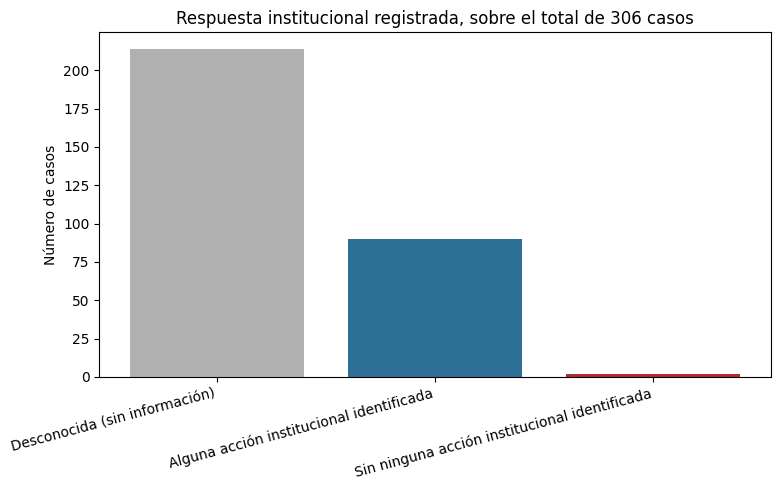

In [4]:
# --- CELDA 4: Gráfico principal — sobre el total, no solo los conocidos ---
colores = {
    'Desconocida (sin información)': '#B0B0B0',
    'Sin ninguna acción institucional identificada': '#B02E2E',
    'Alguna acción institucional identificada': '#2E6F95',
}

plt.figure(figsize=(8, 5))
plt.bar(conteo.index, conteo.values, color=[colores[c] for c in conteo.index])
plt.title('Respuesta institucional registrada, sobre el total de 306 casos')
plt.ylabel('Número de casos')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

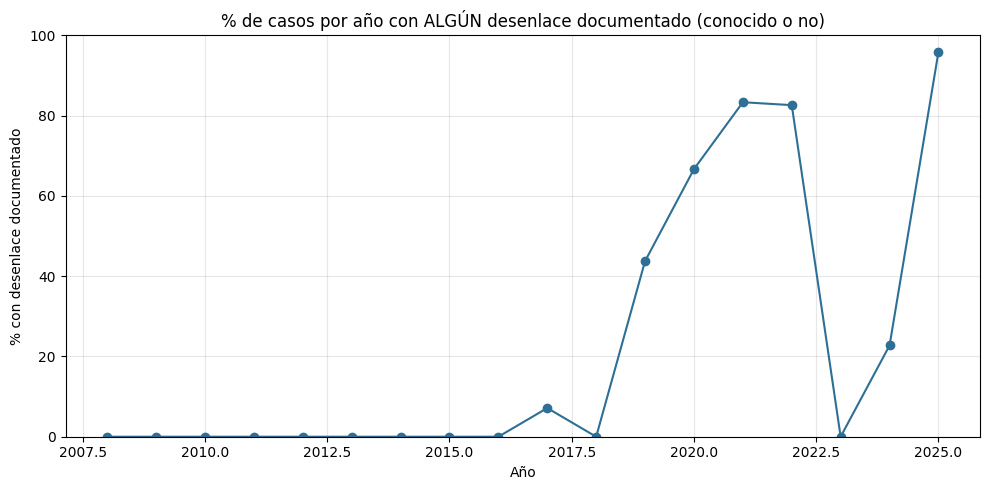

In [5]:
# --- CELDA 5: ¿Mejora con el tiempo la proporción de casos con desenlace conocido? ---
# Esto no mide si la justicia mejora — mide si el MONITOREO y seguimiento
# de los casos mejora, lo cual es una pregunta distinta pero también
# relevante para el artículo.
por_año = col.groupby('Calendar year')['estado_respuesta_institucional'].apply(
    lambda x: (x != 'Desconocida (sin información)').mean() * 100
)

plt.figure(figsize=(10, 5))
plt.plot(por_año.index, por_año.values, marker='o', color='#2E6F95')
plt.title('% de casos por año con ALGÚN desenlace documentado (conocido o no)')
plt.xlabel('Año')
plt.ylabel('% con desenlace documentado')
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# --- CELDA 6: Cruce con identidad de género (revisando tamaño de celda) ---
cruce = pd.crosstab(col['Gender identity or expression'].fillna('Sin dato'),
                     col['estado_respuesta_institucional'])
print("\nRespuesta institucional por identidad de género:")
print(cruce)
print("\nADVERTENCIA: revisa que ninguna celda citada en el texto tenga menos")
print("de 5 casos.")


Respuesta institucional por identidad de género:
estado_respuesta_institucional                      Alguna acción institucional identificada  \
Gender identity or expression                                                                  
hombre trans / trans masculino / hombre transgé...                                         4   
mujer trans / trans femenina / trans femme / mu...                                        73   
mujer transexual                                                                           3   
no-binarie                                                                                 0   
otro                                                                                       1   
trans / transgénero                                                                        9   
travesti                                                                                   0   

estado_respuesta_institucional                      Desconocida (sin información)  \


In [7]:
# --- CELDA 7: Exportar ---
resumen_final = pd.DataFrame({
    'categoría': conteo.index,
    'casos': conteo.values,
    'porcentaje_sobre_total': porcentaje.values.round(1)
})
resumen_final.to_csv('/content/resumen_respuesta_institucional.csv', index=False)
por_año.to_csv('/content/desenlace_documentado_por_año.csv')
print("\nExportado: resumen_respuesta_institucional.csv, desenlace_documentado_por_año.csv")


Exportado: resumen_respuesta_institucional.csv, desenlace_documentado_por_año.csv
